# Exercício Regressão Linear com PyTorch

O objetivo desse notebook é reescrevê-lo porém utilizando tensores do PyTorch.

Os nomes das funções do PyTorch são próximas das funções do Torch original escrito
na linguagem Lua, porém não são iguais.

## Importação dos pacotes

In [ ]:
%matplotlib inline
import torch

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

def print_assert(r):
    if r:
        return 'OK!'
    else:
        return 'Incorreto!'

## Dataset

### Leitura dos dados

In [ ]:
import pandas as pd
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_in = data[:,0:1]
y_in = data[:,1:2]

x_train = torch.FloatTensor(x_in)
y_train = torch.FloatTensor(y_in)

n_samples = x_train.size(0)
print('x_train.shape:',x_train.shape, type(x_train))
print('y_train.shape:',y_train.shape, type(y_train))

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

iris_pd = pd.DataFrame(x_in, columns=['x_in'])
iris_pd['y_in'] = y_in
iris_pd.head()

x_train.shape: torch.Size([50, 1]) <class 'torch.Tensor'>
y_train.shape: torch.Size([50, 1]) <class 'torch.Tensor'>
x_train[:5]:
 tensor([[7.0000],
        [6.4000],
        [6.9000],
        [5.5000],
        [6.5000]])
y_train[:5]:
 tensor([[4.7000],
        [4.5000],
        [4.9000],
        [4.0000],
        [4.6000]])


,x_in,y_in
0,7.0,4.7
1,6.4,4.5
2,6.9,4.9
3,5.5,4.0
4,6.5,4.6


### Normalização dos dados

Text(0, 0.5, 'Comprimento petalas')

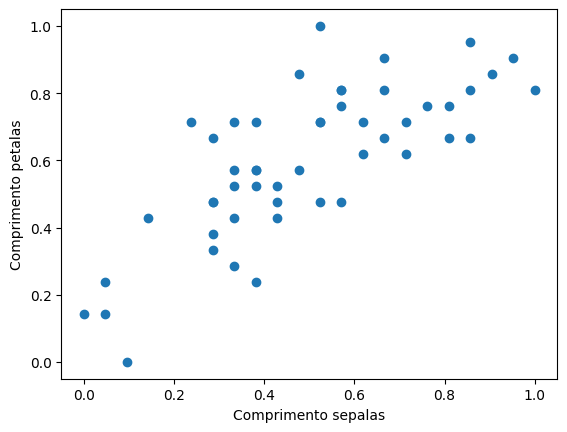

In [ ]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

### Exercício 1 - Criação do `x_train_bias`

faça o `x_train_bias` ser uma matriz com 1s na primeira coluna e x_train na segunda coluna.




Dica: você pode precisar da função [torch.cat](http://pytorch.org/docs/master/torch.html#torch.cat) e [torch.ones](http://pytorch.org/docs/master/torch.html#torch.ones).

In [ ]:
# Exercício 1: criar x_train_bias com tensores PyTorch
x_train_bias = torch.cat([torch.ones(n_samples, 1), x_train], dim=1)
print('x_train_bias shape:', x_train_bias.size())


x_train_bias shape: torch.Size([50, 2])


In [ ]:
# Verificação do exercício - Execute para testar sua implementação

print('x_train_bias é um tensor: {}'.format(print_assert(
    isinstance(x_train_bias, torch.FloatTensor)
)))

print('tamanho do x_train_bias: {}'.format(print_assert(
    x_train_bias.size() == torch.Size([50, 2])
)))

print('primeira coluna é só de uns: {}'.format(print_assert(
    (x_train_bias[:, 0] - torch.ones(n_samples)).sum() == 0
)))

print('segunda coluna é igual a x_train: {}'.format(print_assert(
    (x_train_bias[:, 1] - x_train.reshape(50)).sum() == 0
)))


x_train_bias é um tensor: OK!
tamanho do x_train_bias: OK!
primeira coluna é só de uns: OK!
segunda coluna é igual a x_train: OK!


## Modelo da rede

### Definição da classe

In [ ]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = torch.Tensor(n_out, n_in)
        self.w.uniform_(-0.1,0.1) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.matmul(torch.t(self.w))


### Instanciando a rede

In [ ]:
model = Net(2,1)

### Testando o predict da rede

In [ ]:
model.forward(torch.ones((4,2)))
#model.forward(torch.randn(4,2))

tensor([[-0.1138],
        [-0.1138],
        [-0.1138],
        [-0.1138]])

## Treinamento

### Exercício 2 - Treinamento

Refaça o código de treinamento da rede, mas agora utilizando somente Tensores do PyTorch. Faça o mesmo procedimento que o notebook [LinearRegressionIrisNumPy](LinearRegressionIrisNumPy.ipynb). Para consultar as operações disponíveis no PyTorch use a [documentação do PyTorch](http://pytorch.org/docs/master/torch.html).

Funções que podem ser úteis:
- torch.t
- torch.mean
- torch.matmul

In [ ]:
num_epochs = 100
learning_rate = 0.5
for epoch in range(num_epochs):

    # forward - predict
    y_pred = model.forward(x_train_bias)

    # loss - usando operações de tensor PyTorch
    loss = torch.mean((y_pred - y_train) ** 2)

    # cálculo do gradiente pelas derivadas parciais
    w_grad = (2.0 / n_samples) * torch.t(x_train_bias).mm(
        x_train_bias.mm(torch.t(model.w)) - y_train
    )

    # gradiente descendente
    model.w = model.w - learning_rate * torch.t(w_grad)

    # verbose
    if (epoch + 1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'.format(epoch+1, num_epochs, loss.item()))


Epoch[20/100], loss: 0.022786
Epoch[40/100], loss: 0.021403
Epoch[60/100], loss: 0.021203
Epoch[80/100], loss: 0.021174
Epoch[100/100], loss: 0.021170


## Avaliação

### Predict

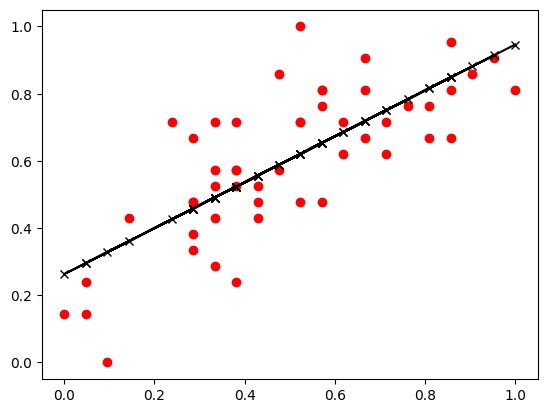

In [ ]:
y_pred = model.forward(x_train_bias)
plt.plot(x_train.numpy(), y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train.numpy(), y_pred.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Parâmetro treinado

In [ ]:
print(model.w)

tensor([[0.2630, 0.6832]])


In [ ]:
x_bias = x_train_bias
y = y_train
w_opt = (torch.inverse(x_bias.t().mm(x_bias)).mm(x_bias.t())).mm(y)
print(w_opt.t())

tensor([[0.2613, 0.6865]])


## Exercício 1 — MSE após treinamento (usando `criterion`)


In [ ]:
# Exercício 1: Calcular MSE com criterion
import torch.nn as nn
criterion = nn.MSELoss()
y_pred_final = model.forward(x_train_bias)
loss_final = criterion(y_pred_final, y_train)
print(f'MSE final após treinamento: {loss_final.item():.6f}')


MSE final após treinamento: 0.021170


## Exercício 2 — Scatter plot da evolução dos parâmetros


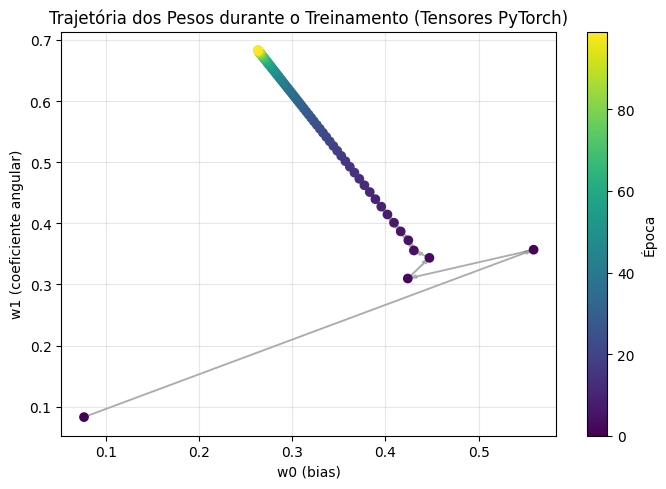

In [ ]:
# Exercício 2: Re-treinar guardando w0 e w1 para plot
import matplotlib.pyplot as plt

# Re-criar modelo
import torch
torch.manual_seed(42)
model2 = Net(2, 1)

w0_list, w1_list = [], []
num_epochs_2 = 100
learning_rate_2 = 0.5

for epoch in range(num_epochs_2):
    w0_list.append(model2.w[0][0].item())
    w1_list.append(model2.w[0][1].item())

    y_pred2 = model2.forward(x_train_bias)
    loss2 = torch.mean((y_pred2 - y_train) ** 2)
    w_grad2 = (2.0 / n_samples) * torch.t(x_train_bias).mm(
        x_train_bias.mm(torch.t(model2.w)) - y_train
    )
    model2.w = model2.w - learning_rate_2 * torch.t(w_grad2)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(w0_list, w1_list, c=range(num_epochs_2), cmap='viridis', zorder=5)
w0_old = None
for (w0, w1) in zip(w0_list, w1_list):
    if w0_old is not None:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01, head_width=0.005, shape='full',
                  length_includes_head=True, color='gray', alpha=0.5)
    w0_old, w1_old = w0, w1

plt.colorbar(label='Época')
plt.xlabel('w0 (bias)')
plt.ylabel('w1 (coeficiente angular)')
plt.title('Trajetória dos Pesos durante o Treinamento (Tensores PyTorch)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Aprendizados — NumPy vs. Tensores PyTorch

### Principais Diferenças de Sintaxe e Comportamento

| Operação | NumPy | PyTorch Tensor |
|---|---|---|
| Multiplicação matricial | `A.dot(B)` / `A @ B` | `A.mm(B)` / `torch.matmul(A, B)` |
| Transposta | `A.T` | `torch.t(A)` |
| Média | `np.mean(x)` | `torch.mean(x)` |
| Potência elemento-a-elemento | `x**2` | `x**2` (igual!) |
| Concatenação horizontal | `np.hstack([A, B])` | `torch.cat([A, B], dim=1)` |
| Ones | `np.ones((n, 1))` | `torch.ones(n, 1)` |
| Extrair valor escalar | `float(x)` | `x.item()` |

### Diferenças de Comportamento
1. **Tipo de dado:** PyTorch usa `FloatTensor` (float32) por padrão para redes neurais — NumPy usa `float64`. É preciso converter os dados explicitamente.
2. **Autograd:** Os tensores PyTorch suportam diferenciação automática (`requires_grad=True`). Neste notebook ainda calculamos o gradiente manualmente, mas a estrutura de tensores já prepara o terreno para o Autograd.
3. **GPU:** Tensores PyTorch podem ser movidos para GPU com `.cuda()`. Arrays NumPy vivem apenas na CPU.
4. **Integração com nn.Module:** A sintaxe de tensores PyTorch é diretamente compatível com as camadas do `torch.nn`, permitindo migração incremental do código.
